In [1]:
#import mortality rate of under 5, for all country
#Data Preparation
!pip install pycountry
import pandas as pd
import pycountry

url = "https://ourworldindata.org/grapher/under-5-mortality-rate-sdgs.csv?v=1&csvType=full&useColumnShortNames=true"
mortality_under_5 = pd.read_csv(url, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})
print(mortality_under_5.head())

#The mortality rate was collected in per 100, the rate was coverted to per 1000 by multipying per 100 to work with the general recorded rate of per 1000
mortality_under_5["per_1000"] = mortality_under_5["observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births"] * 10
mortality_under_5.head()

#The name of countries and their ISO code in existence
countries = []
for c in pycountry.countries:
    countries.append({
        'country_name': c.name,
        'iso_alpha3': c.alpha_3
    })

iso_data = pd.DataFrame(countries).sort_values('country_name').reset_index(drop=True)
print(iso_data.head())

#Rename the column that contains the code for each country of iso data, so it can be merge with under_5 mortality data
iso_data = iso_data.rename(columns={'iso_alpha3': 'code', "country_name":"entity"})
iso_data.head()

#Merge under_5_mertality data on the left with iso_data so as to filter the data to all country,
#because the under_5_mortality data as some world back indicator in between which does not belong to any country
mortality_under_5_new = pd.merge(mortality_under_5, iso_data, on=['code', "entity"], how='left')
mortality_under_5_new.head()

#Validating my new data
print(mortality_under_5.shape)
print(mortality_under_5_new.shape)

#Then merge isn't the proper method, i will try filter method
mortality_under_5_new_2 = mortality_under_5[mortality_under_5["code"].isin(iso_data["code"])]
print(mortality_under_5_new_2.shape)
mortality_under_5_new_2.head()

#validating if we have all countries in the list
print(mortality_under_5_new_2["code"].unique())
unique_coutries = mortality_under_5_new_2["code"].unique()
print(len(unique_coutries))

#Importing data for income category for each country
import requests
import pandas as pd

# Pull country metadata including income classification
url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
response = requests.get(url)
data = response.json()[1]
# index 0 is pagination info, index 1 is the actual data

# Flatten the nested structure
income_level = pd.DataFrame([
    {
        "Code": c["id"],
        "country_name": c["name"],
        "income_group": c["incomeLevel"]["value"],
        "region": c["region"]["value"]
    }
    for c in data
])

# Drop non-country aggregates (World Bank includes regional groupings here too)
income_level = income_level[income_level["income_group"] != "Aggregates"]

print(income_level["income_group"].unique())
income_level.head()

#Now i have my income level data, so i will like extract two columns from it to the mortarlity data
mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['region'])
print(mortality_under_5_new_2.head())
print(mortality_under_5_new_2["income_level"].unique())
print(mortality_under_5_new_2["regions"].unique())


#I waant to drop missing value in the data
mort_und_5_new_2_dropna = mortality_under_5_new_2.dropna()
print(mort_und_5_new_2_dropna.shape)
print(mort_und_5_new_2_dropna.isna().sum())

#Since my interest is working on years from year 2000 to later year.
mort_und_5_new_2_dropna_2000 = mort_und_5_new_2_dropna[mort_und_5_new_2_dropna["year"] >= 2000]
print(mort_und_5_new_2_dropna_2000.shape)

#validating which countries have dropped since i applied dropping missing valuea nd also
#applied filtered for years above 2000
print(mort_und_5_new_2_dropna_2000["code"].unique())
unique_coutries_2 = mort_und_5_new_2_dropna_2000["code"].unique()
print(len(unique_coutries_2))

# Rename data
mortality_under_5 = mort_und_5_new_2_dropna_2000
print(mortality_under_5.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 32.9 MB/s eta 0:00:00
        entity code  year  \
0  Afghanistan  AFG  1957   
1  Afghanistan  AFG  1958   
2  Afghanistan  AFG  1959   
3  Afghanistan  AFG  1960   
4  Afghanistan  AFG  1961   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  
0                                          36.819660                                                                                
1                                          36.206852                                                                                
2                                          35.644524                                                                                
3                                          35.055080                                                                                
4                                          34.519325                               

/tmp/ipykernel_1561/582659671.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
/tmp/ipykernel_1561/582659671.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Cod

In [2]:
#cHECKING FOR MISSING VALUE
print(mortality_under_5.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4875 entries, 43 to 13979
Data columns (total 7 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype  
---  ------                                                                                                                           --------------  -----  
 0   entity                                                                                                                           4875 non-null   object 
 1   code                                                                                                                             4875 non-null   object 
 2   year                                                                                                                             4875 non-null   int64  
 3   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_d

In [3]:
#groupings based on income level
group = mortality_under_5.groupby("income_level")["per_1000"].agg(['mean', 'median', 'std', 'count']).reset_index()
print(group.head())

          income_level       mean     median        std  count
0          High income   8.219385   5.787534   6.637771   1625
1           Low income  98.886497  92.232485  52.509548    625
2  Lower middle income  57.878429  53.093877  33.301787   1175
3  Upper middle income  23.441021  18.957453  17.419735   1450


In [4]:
print(group.shape)  # or whatever your grouped variable is called
print(group.head(10))

(4, 5)
          income_level       mean     median        std  count
0          High income   8.219385   5.787534   6.637771   1625
1           Low income  98.886497  92.232485  52.509548    625
2  Lower middle income  57.878429  53.093877  33.301787   1175
3  Upper middle income  23.441021  18.957453  17.419735   1450


In [5]:
#The right way to generate the data for Anova
# Step 1: Group by country identifiers + income_group, average the mortality rate across all years
country_avg = mortality_under_5.groupby(['code', 'entity', 'income_level'])['per_1000'].mean().reset_index()

print(country_avg.shape)
print(country_avg.head(10))

(195, 4)
  code                entity         income_level   per_1000
0  AFG           Afghanistan           Low income  85.698339
1  AGO                Angola  Lower middle income  91.690323
2  ALB               Albania  Upper middle income  14.319662
3  AND               Andorra          High income   4.449788
4  ARE  United Arab Emirates          High income   8.088060
5  ARG             Argentina  Upper middle income  13.680276
6  ARM               Armenia  Upper middle income  18.071934
7  ATG   Antigua and Barbuda          High income  11.762595
8  AUS             Australia          High income   4.649689
9  AUT               Austria          High income   4.188702


In [6]:
#Anova
from scipy import stats

groups = [country_avg[country_avg['income_level'] == g]['per_1000'].dropna()
          for g in country_avg['income_level'].dropna().unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.6f}")

F-statistic: 129.07, p-value: 0.000000


In [7]:
#Tukey test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey1 = pairwise_tukeyhsd(
    endog=country_avg.dropna(subset=['per_1000', 'income_level'])['per_1000'],
    groups=country_avg.dropna(subset=['per_1000', 'income_level'])['income_level'],
    alpha=0.05
)
print(tukey1)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1              group2       meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------------
        High income          Low income  90.6671    0.0  77.4923 103.8419   True
        High income Lower middle income   49.659    0.0  38.9401   60.378   True
        High income Upper middle income  15.2216 0.0008   5.1098  25.3335   True
         Low income Lower middle income -41.0081    0.0 -54.8659 -27.1502   True
         Low income Upper middle income -75.4455    0.0 -88.8393 -62.0517   True
Lower middle income Upper middle income -34.4374    0.0 -45.4244 -23.4504   True
--------------------------------------------------------------------------------


In [8]:
from scipy import stats

groups = [mortality_under_5[mortality_under_5['income_level'] == g]['per_1000'].dropna()
          for g in mortality_under_5['income_level'].dropna().unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.6f}")

F-statistic: 2075.16, p-value: 0.000000


In [9]:
alpha = 0.05
if p_value < alpha:
    print("Statistically significant difference in U5MR across income groups (p < 0.05)")
else:
    print("No statistically significant difference found")

Statistically significant difference in U5MR across income groups (p < 0.05)


In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mortality_under_5['per_1000'].dropna(),
    groups=mortality_under_5.dropna(subset=['per_1000', 'income_level'])['income_level'],
    alpha=0.05
)
print(tukey)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj  lower    upper   reject
-------------------------------------------------------------------------------
        High income          Low income  90.6671   0.0  87.4091  93.9251   True
        High income Lower middle income   49.659   0.0  47.0083  52.3098   True
        High income Upper middle income  15.2216   0.0  12.7211  17.7222   True
         Low income Lower middle income -41.0081   0.0  -44.435 -37.5811   True
         Low income Upper middle income -75.4455   0.0 -78.7577 -72.1333   True
Lower middle income Upper middle income -34.4374   0.0 -37.1544 -31.7204   True
-------------------------------------------------------------------------------


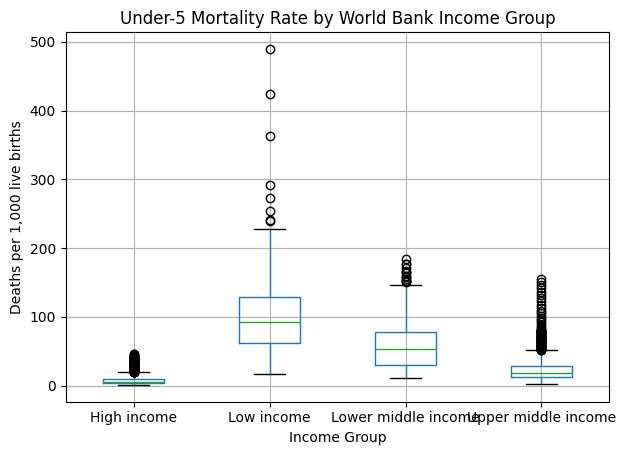

In [11]:
import matplotlib.pyplot as plt

mortality_under_5.boxplot(column='per_1000', by='income_level')
plt.title('Under-5 Mortality Rate by World Bank Income Group')
plt.suptitle('')
plt.xlabel('Income Group')
plt.ylabel('Deaths per 1,000 live births')
plt.tight_layout()
#plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge'}/global_trend_since_2000.png', dpi=200)
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge'}/boxplot_by_income_group.png', dpi=200)
plt.show()

In [12]:
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Run Tukey HSD (same as before)
tukey_1 = pairwise_tukeyhsd(
    endog=mortality_under_5.dropna(subset=['per_1000', 'income_level'])['per_1000'],
    groups=mortality_under_5.dropna(subset=['per_1000', 'income_level'])['income_level'],
    alpha=0.05
)

# Convert Tukey results into a DataFrame for plotting
tukey_df = pd.DataFrame(data=tukey_1._results_table.data[1:], columns=tukey._results_table.data[0])
tukey_df['comparison'] = tukey_df['group2'] + '-' + tukey_df['group1']

# Sort so the largest comparisons appear at top (optional, matches reference image style)
tukey_df = tukey_df.sort_values('meandiff', ascending=True).reset_index(drop=True)

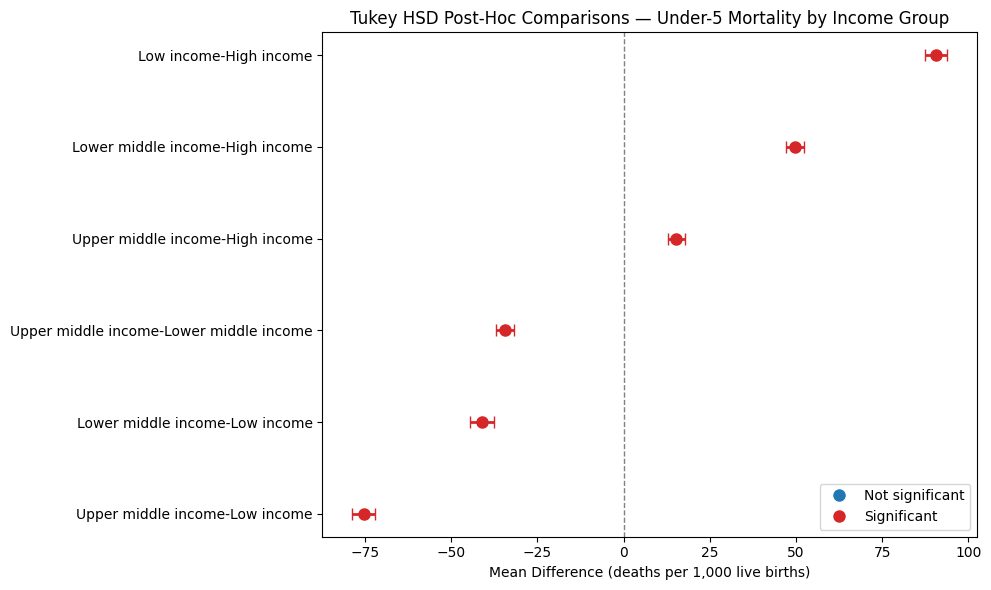

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, row in tukey_df.iterrows():
    color = '#d62728' if row['reject'] else '#1f77b4'  # red if significant, blue if not
    lower = row['meandiff'] - row['lower']
    upper = row['upper'] - row['meandiff']

    ax.errorbar(
        x=row['meandiff'], y=i,
        xerr=[[lower], [upper]],
        fmt='o', color=color, ecolor=color,
        capsize=4, markersize=8, linewidth=2
    )

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df['comparison'])
ax.set_xlabel('Mean Difference (deaths per 1,000 live births)')
ax.set_title("Tukey HSD Post-Hoc Comparisons — Under-5 Mortality by Income Group")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=10, label='Not significant'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Significant'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge'}/tukey_hsd_income_groups.png', dpi=200)
plt.show()

In [14]:
mortality_under_5_vs_pop = pd.read_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/mortality_under_5_pop.csv")
print(mortality_under_5_vs_pop.head())

        entity code  year  \
0  Afghanistan  AFG  2000   
1  Afghanistan  AFG  2001   
2  Afghanistan  AFG  2002   
3  Afghanistan  AFG  2003   
4  Afghanistan  AFG  2004   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  \
0                                          13.170724                                                                                 
1                                          12.747986                                                                                 
2                                          12.307344                                                                                 
3                                          11.854750                                                                                 
4                                          11.394402                                                                                 

    per_1000 income_

In [15]:
print(mortality_under_5_vs_pop.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 10 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype  
---  ------                                                                                                                           --------------  -----  
 0   entity                                                                                                                           4875 non-null   object 
 1   code                                                                                                                             4875 non-null   object 
 2   year                                                                                                                             4875 non-null   int64  
 3   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measu

In [16]:
#Correlation
from scipy import stats

# Pearson correlation
corr, p_value = stats.pearsonr(mortality_under_5_vs_pop['population'], mortality_under_5_vs_pop['per_1000'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.6f}")

Correlation: nan, p-value: nan


In [17]:
#create a new data set where we have only population and per_1000
# Keep only rows where BOTH columns have valid data
pop_per_1000 = mortality_under_5_vs_pop.dropna(subset=['population', 'per_1000'])
print(pop_per_1000.head())

corr, p_value = stats.pearsonr(pop_per_1000['population'], pop_per_1000['per_1000'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.6f}")
print(f"N used: {len(pop_per_1000)}")

        entity code  year  \
0  Afghanistan  AFG  2000   
1  Afghanistan  AFG  2001   
2  Afghanistan  AFG  2002   
3  Afghanistan  AFG  2003   
4  Afghanistan  AFG  2004   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  \
0                                          13.170724                                                                                 
1                                          12.747986                                                                                 
2                                          12.307344                                                                                 
3                                          11.854750                                                                                 
4                                          11.394402                                                                                 

    per_1000 income_

In [18]:
pop_per_1000_latest = pop_per_1000[pop_per_1000['year'] == 2024]
print(pop_per_1000_latest.head())

          entity code  year  \
24   Afghanistan  AFG  2024   
49       Albania  ALB  2024   
74       Algeria  DZA  2024   
99       Andorra  AND  2024   
124       Angola  AGO  2024   

     observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  \
24                                            5.303202                                                                                 
49                                            0.922708                                                                                 
74                                            2.164028                                                                                 
99                                            0.250713                                                                                 
124                                           4.899967                                                                               

In [20]:
#Let me try log transformation
# Log-population version
import numpy as np
pop_per_1000['log_population'] = np.log(pop_per_1000['population'])
corr_log, p_log = stats.pearsonr(pop_per_1000['log_population'], pop_per_1000['per_1000'])
print(f"Correlation: {corr_log:.3f}, p-value: {p_log:.6f}")

Correlation: 0.152, p-value: 0.000000


/tmp/ipykernel_1561/1759640076.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_per_1000['log_population'] = np.log(pop_per_1000['population'])


In [21]:
#Correlation for untransformed value of population
corr, p_value = stats.pearsonr(pop_per_1000_latest['population'], pop_per_1000_latest['per_1000'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.6f}")
print(f"N used: {len(pop_per_1000_latest)}")

Correlation: 0.004, p-value: 0.954382
N used: 168


In [22]:
#Let me try log transformation for extracted for year 2024 only
# Log-population version
pop_per_1000_latest['log_population'] = np.log(pop_per_1000_latest['population'])
corr_log, p_log = stats.pearsonr(pop_per_1000_latest['log_population'], pop_per_1000_latest['per_1000'])
print(f"Correlation: {corr_log:.3f}, p-value: {p_log:.6f}")

Correlation: 0.184, p-value: 0.016825


/tmp/ipykernel_1561/2441173151.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_per_1000_latest['log_population'] = np.log(pop_per_1000_latest['population'])


In [23]:
#R-squared
r_squared = 0.152 ** 2
print(f"R-squared: {r_squared:.4f} ({r_squared*100:.1f}% of variance explained)")

R-squared: 0.0231 (2.3% of variance explained)


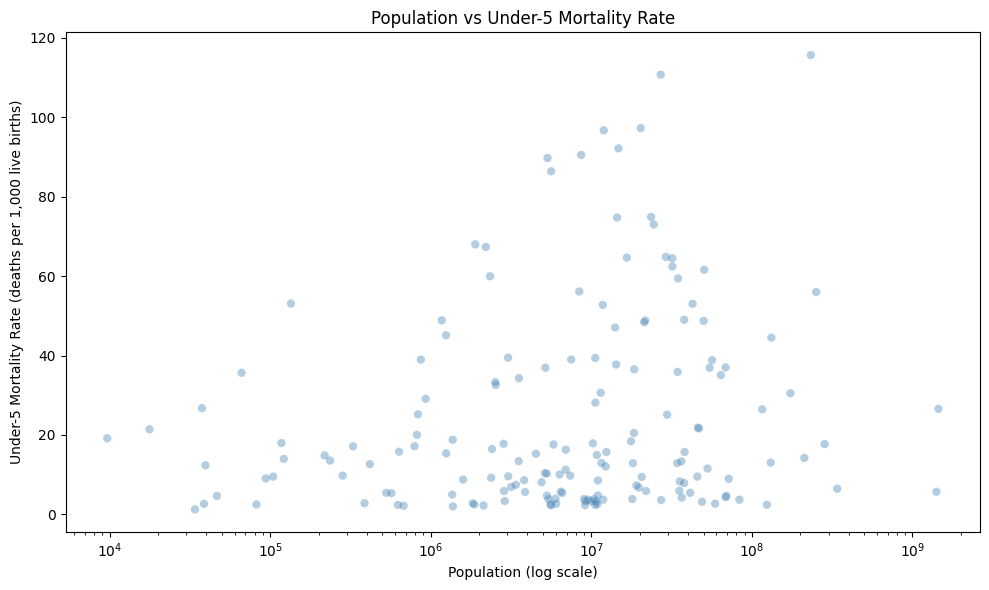

In [25]:
#scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(pop_per_1000_latest['population'], pop_per_1000_latest['per_1000'], alpha=0.4, color='steelblue', edgecolor='none')

plt.xscale('log')  # log scale on x-axis since population is heavily skewed
plt.xlabel('Population (log scale)')
plt.ylabel('Under-5 Mortality Rate (deaths per 1,000 live births)')
plt.title('Population vs Under-5 Mortality Rate')

plt.tight_layout()
#plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge'}/population_vs_mortality_scatter_latest.png', dpi=200)
plt.show()